METING 1


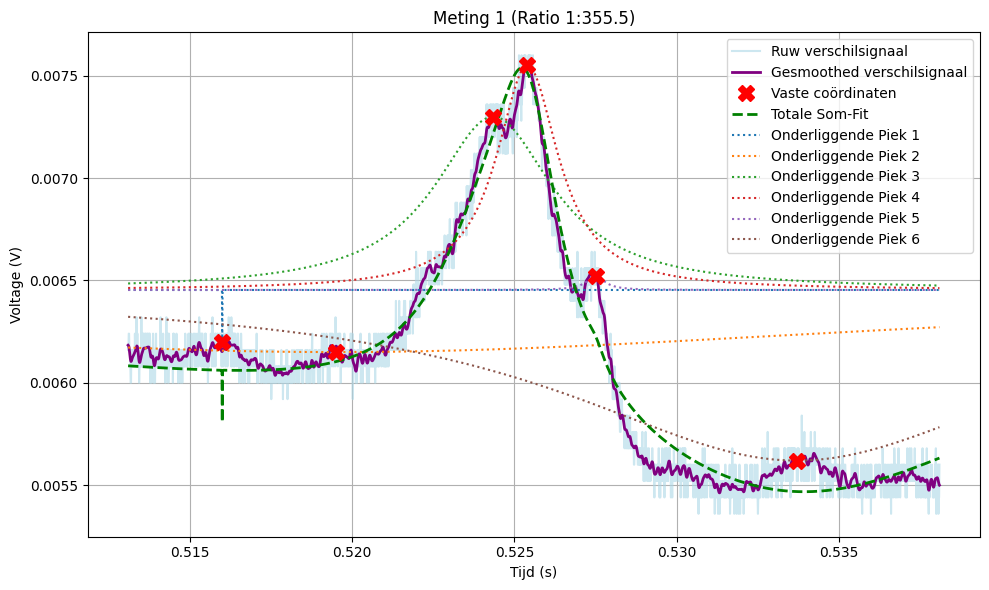

R-squared van de fit: 0.970596

METING 2


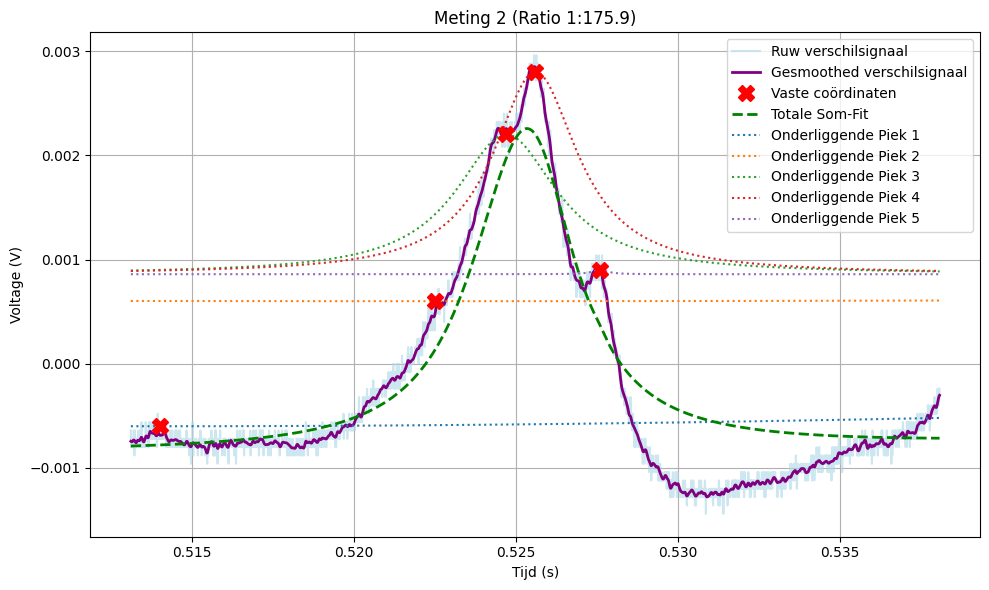

R-squared van de fit: 0.891854

METING 3


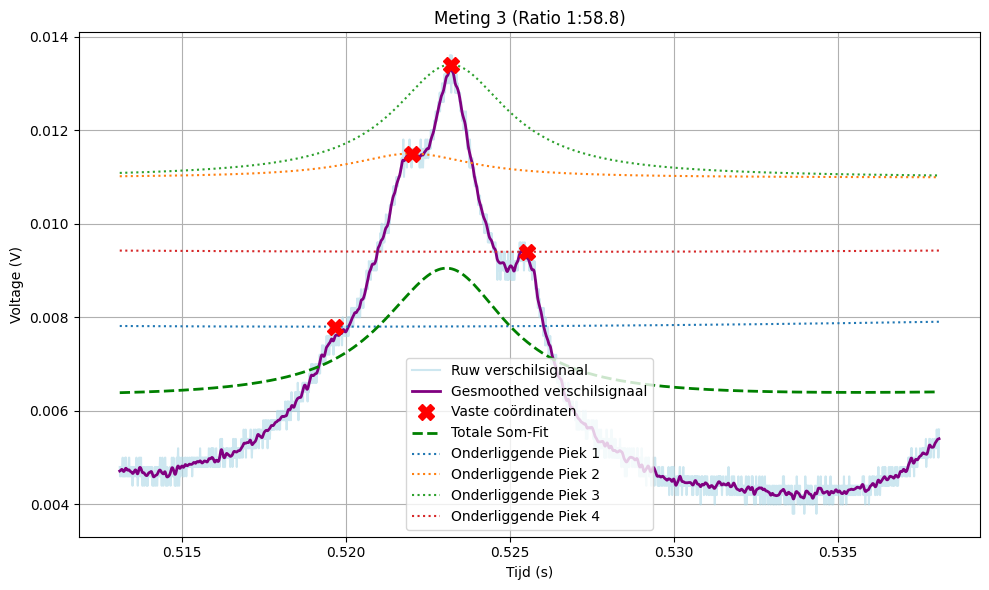

R-squared van de fit: 0.454949

METING 4


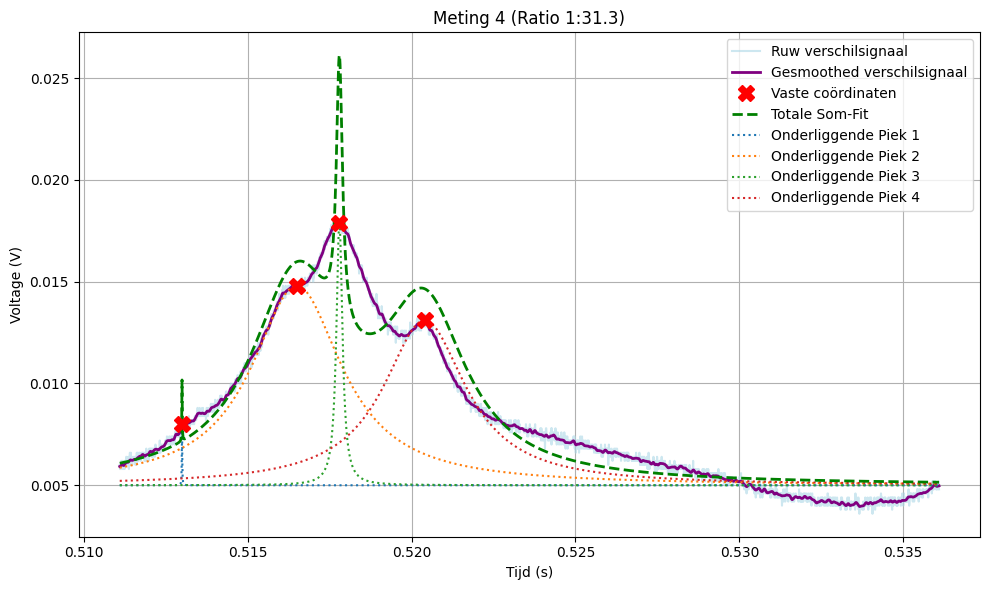

R-squared van de fit: 0.909715

METING 5


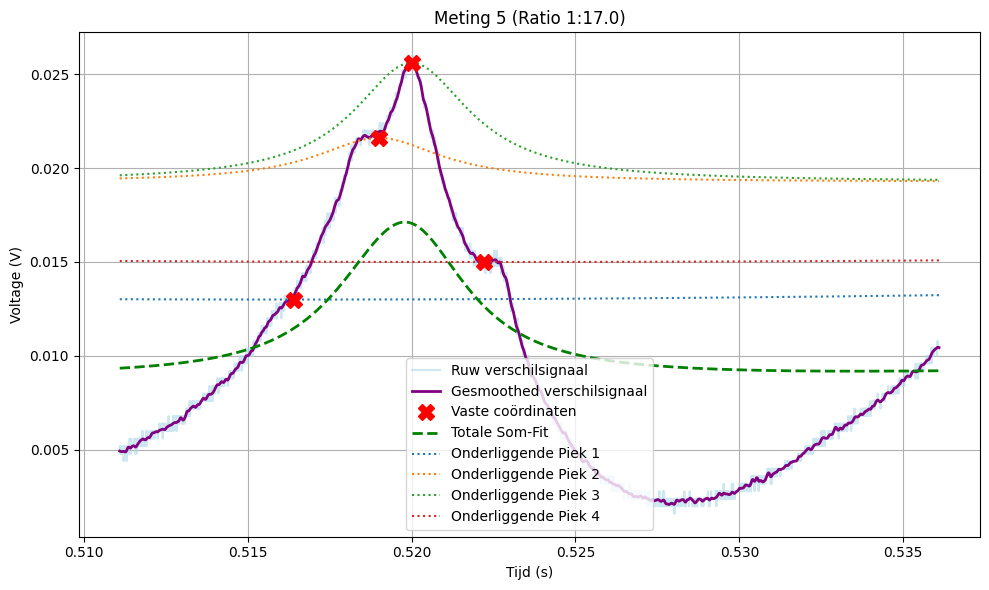

R-squared van de fit: 0.499986

METING 6


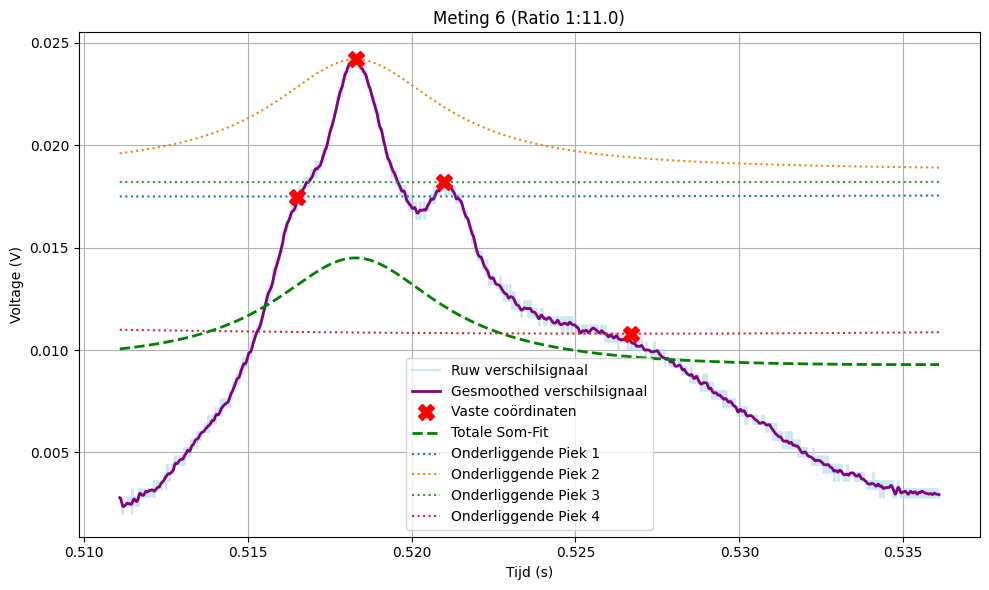

R-squared van de fit: 0.400851

METING 7


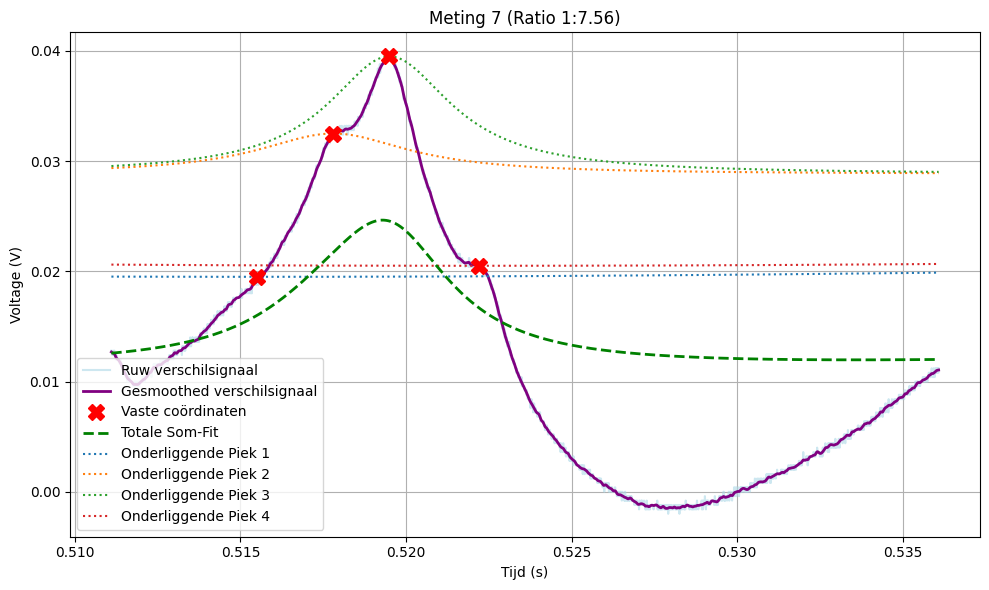

R-squared van de fit: 0.460785

METING 8


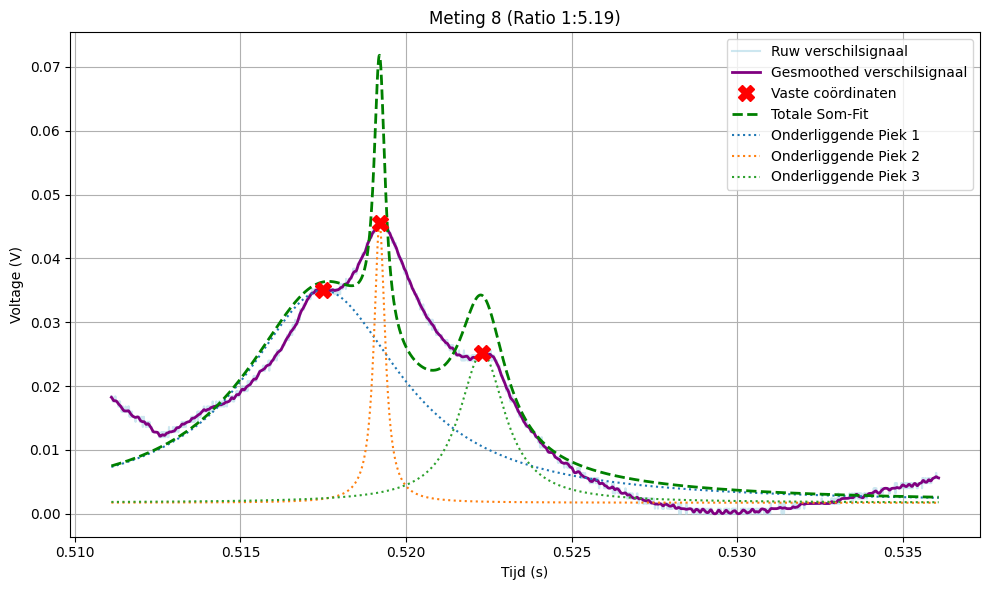

R-squared van de fit: 0.880497

METING 9


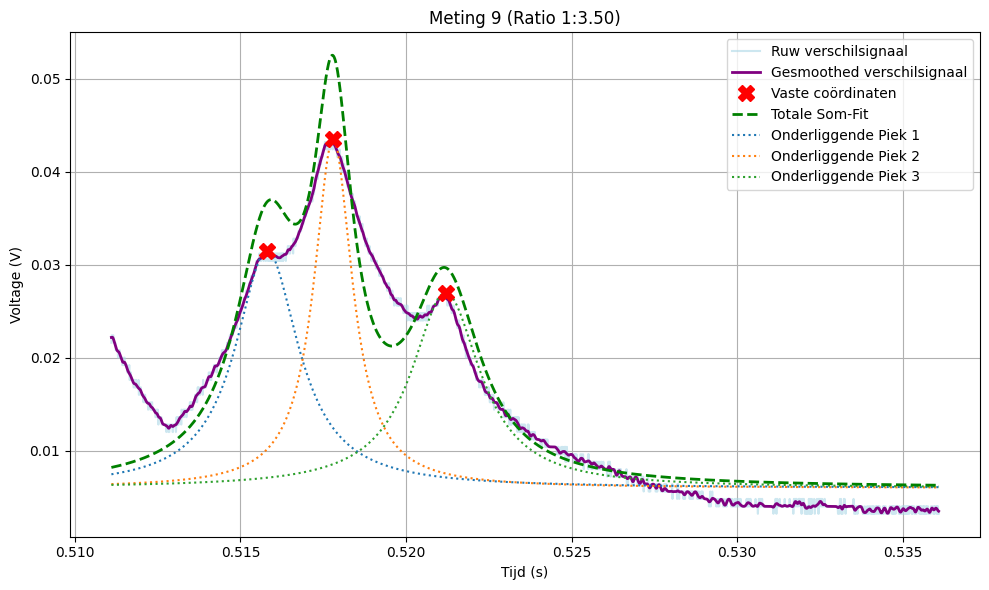

R-squared van de fit: 0.896368

METING 10


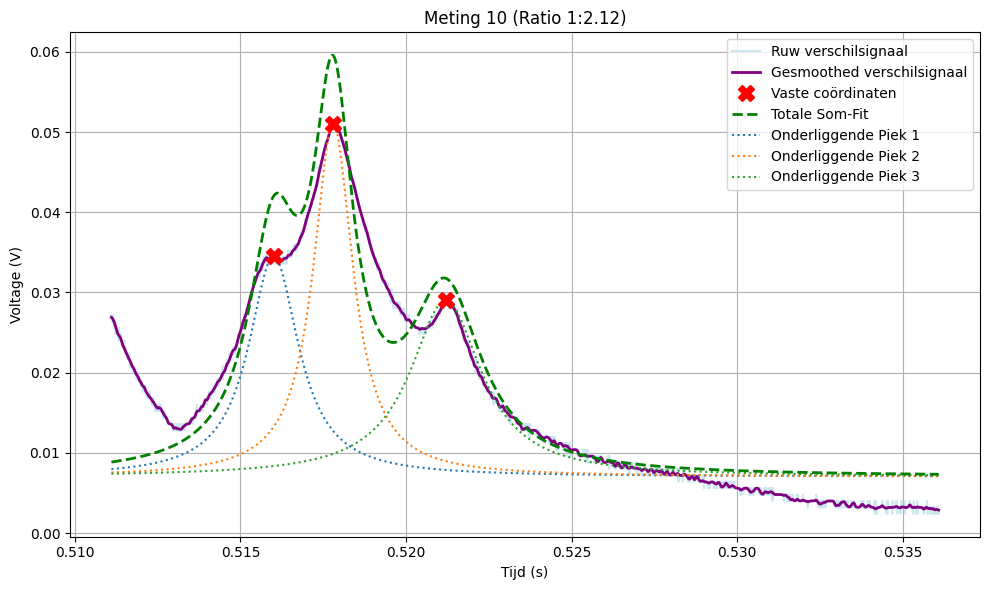

R-squared van de fit: 0.879307

METING 11


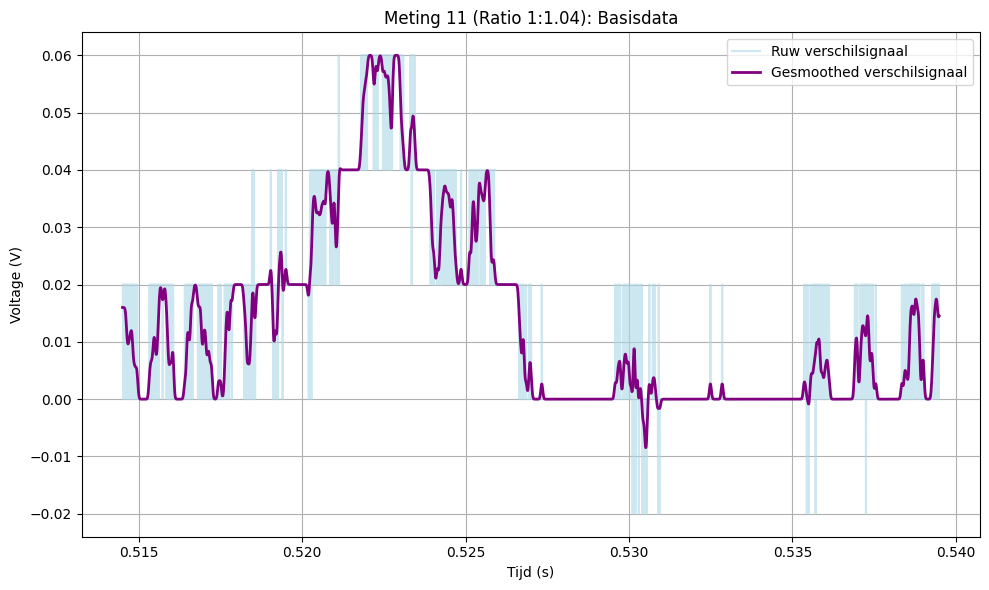

METING 12


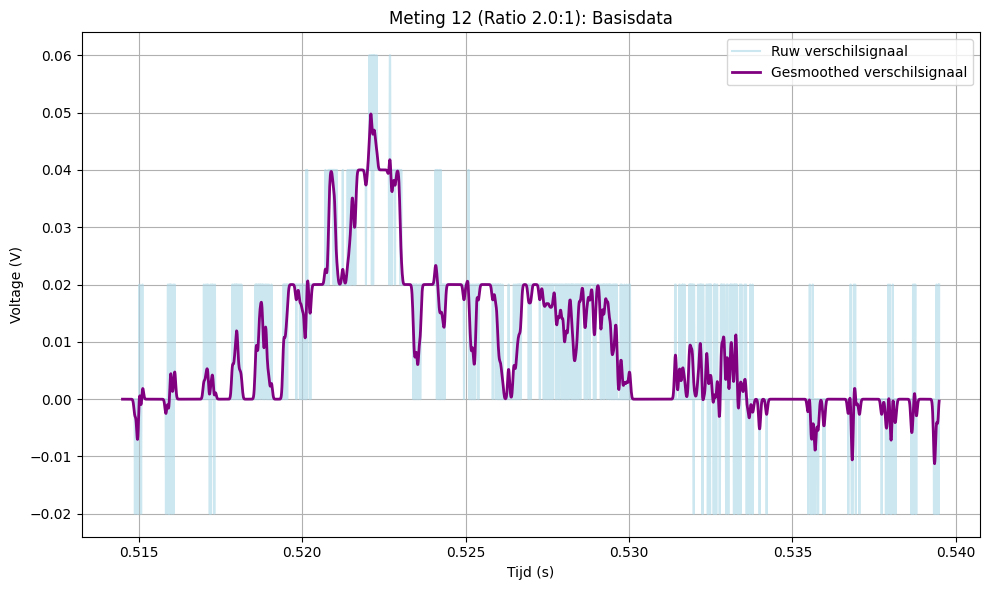

METING 13


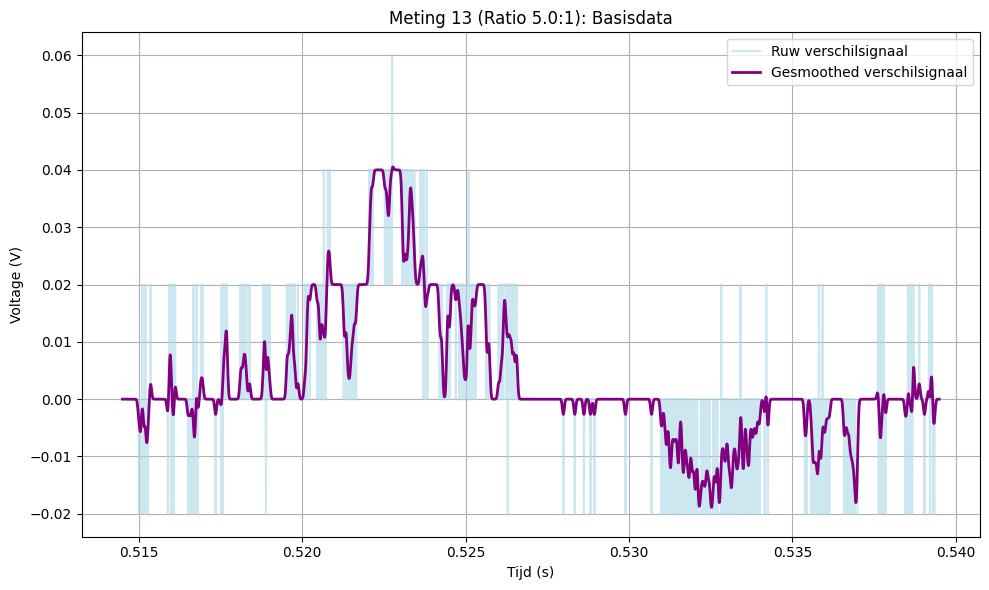

METING 14


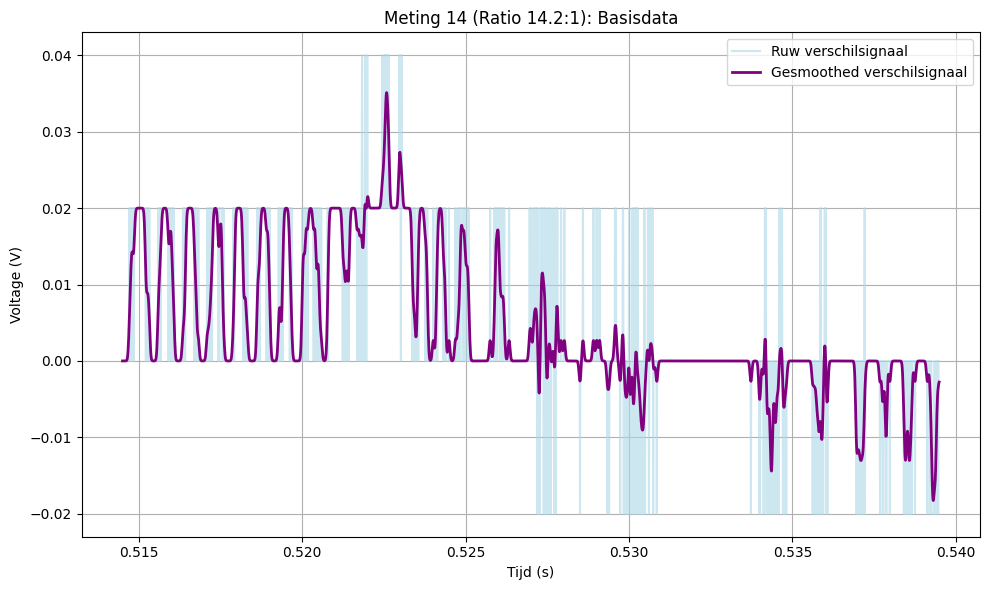

METING 15


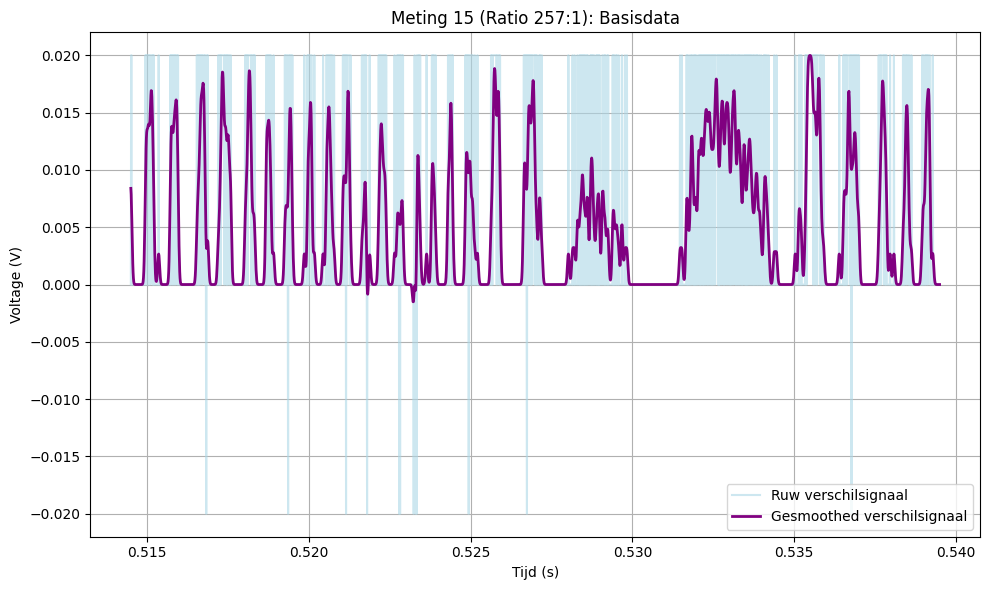

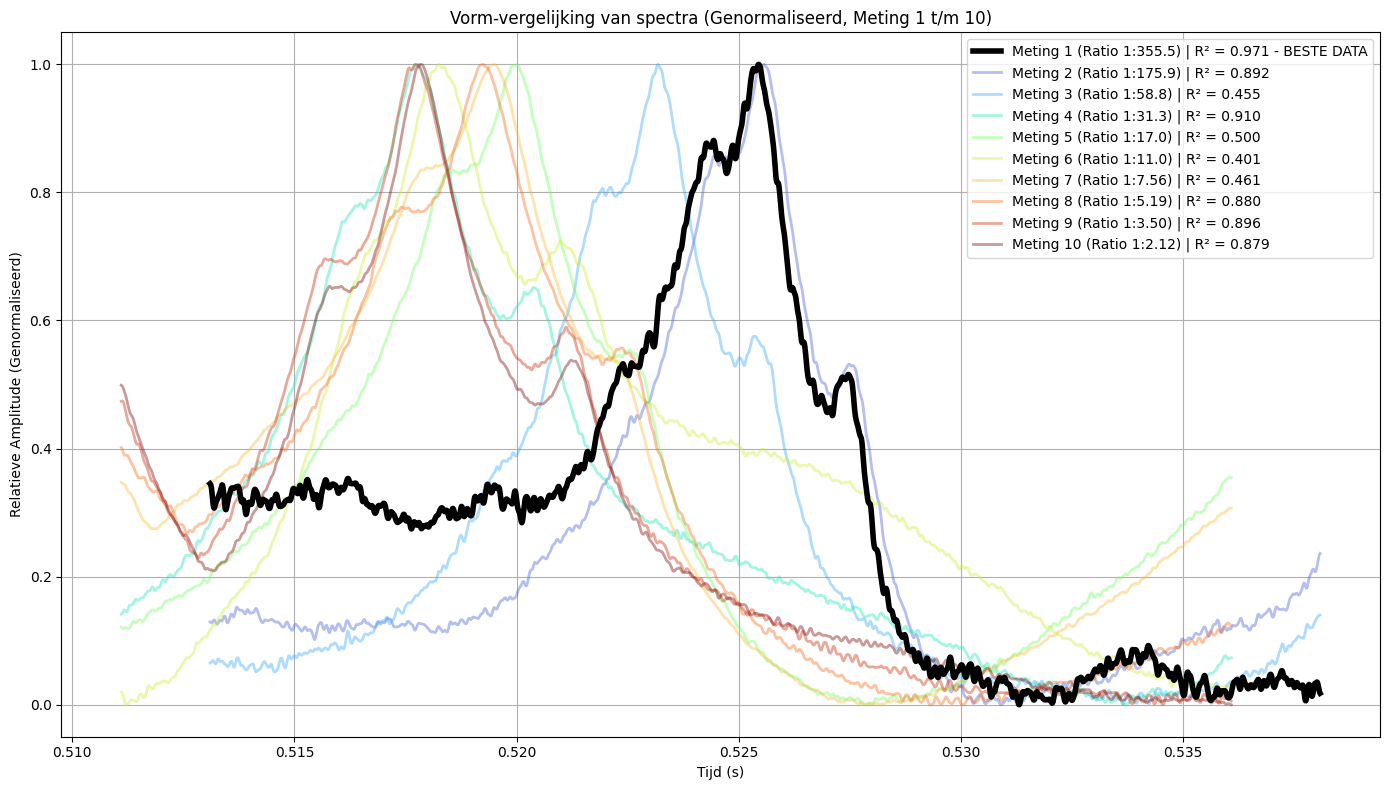

In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
import warnings

warnings.filterwarnings('ignore')

ratios = {
    1: "1:355.5", 2: "1:175.9", 3: "1:58.8", 4: "1:31.3", 5: "1:17.0",
    6: "1:11.0", 7: "1:7.56", 8: "1:5.19", 9: "1:3.50", 10: "1:2.12",
    11: "1:1.04", 12: "2.0:1", 13: "5.0:1", 14: "14.2:1", 15: "257:1"
}

pieken_per_meting = {
    1: [(0.5160, 0.0062), (0.5195, 0.00615), (0.52435, 0.0073), (0.5254, 0.00755), (0.5275, 0.00652), (0.5337, 0.00562)],
    2: [(0.5140, -0.0006), (0.5225, 0.0006), (0.5247, 0.0022), (0.5256, 0.0028), (0.5276, 0.0009)],
    3: [(0.51967, 0.0078), (0.5220, 0.0115), (0.5232, 0.0134), (0.52552, 0.0094)],
    4: [(0.5130, 0.0080), (0.5165, 0.0148), (0.5178, 0.0179), (0.5204, 0.0131)],
    5: [(0.5164, 0.0130), (0.5190, 0.0216), (0.5200, 0.0256), (0.5222, 0.0150)],
    6: [(0.5165, 0.0175), (0.5183, 0.0242), (0.5210, 0.0182), (0.5267, 0.0108)],
    7: [(0.5155, 0.0195), (0.5178, 0.0325), (0.5195, 0.0395), (0.5222, 0.0205)],
    8: [(0.5175, 0.0350), (0.5192, 0.0455), (0.5223, 0.0252)],
    9: [(0.5158, 0.0315), (0.5178, 0.0435), (0.5212, 0.0270)],
    10: [(0.5160, 0.0345), (0.5178, 0.0510), (0.5212, 0.0290)],
    11: [],
    12: [],
    13: [],
    14: [],
    15: []
}

alle_data_voor_plot = []
r_squared_waarden = {}

for idx in range(1, 16):
    print(f"METING {idx}")
    
    file_doppler = f'{idx}f.CSV'
    file_vrij = f'{idx}d.CSV'
    
    try:
        df_doppler = pd.read_csv(file_doppler, header=None, usecols=[3, 4], names=['Tijd', 'Voltage'])
        df_vrij = pd.read_csv(file_vrij, header=None, usecols=[3, 4], names=['Tijd', 'Voltage'])
    except Exception as e:
        print(f"Bestanden voor meting {idx} overgeslagen/niet gevonden.\n")
        continue

    tijd = df_doppler['Tijd'].values
    signaal_doppler = df_doppler['Voltage'].values
    signaal_vrij = df_vrij['Voltage'].values

    verschil_ruw = signaal_doppler - signaal_vrij
    verschil_smoothed = gaussian_filter1d(verschil_ruw, sigma=3)

    alle_data_voor_plot.append((idx, tijd, verschil_smoothed))

    plt.figure(figsize=(10, 6))
    plt.plot(tijd, verschil_ruw, label='Ruw verschilsignaal', color='lightblue', alpha=0.6)
    plt.plot(tijd, verschil_smoothed, label='Gesmoothed verschilsignaal', color='purple', linewidth=2)

    handmatige_pieken = pieken_per_meting.get(idx, [])

    if not handmatige_pieken:
        plt.title(f'Meting {idx} (Ratio {ratios.get(idx, "")}): Basisdata')
        plt.xlabel('Tijd (s)')
        plt.ylabel('Voltage (V)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        continue

    x_hand = [p[0] for p in handmatige_pieken]
    y_hand = [p[1] for p in handmatige_pieken]
    plt.plot(x_hand, y_hand, 'X', color='red', markersize=12, label='Vaste coördinaten', zorder=5)

    try:
        def strict_lorentz(x, *params):
            offset = params[-1]
            y_fit = np.full_like(x, offset, dtype=float)
            
            for i in range(len(x_hand)):
                x0 = x_hand[i]
                a = y_hand[i] - offset 
                gamma = params[i]
                y_fit += a * (gamma**2 / ((x - x0)**2 + gamma**2))
            return y_fit

        p0 = [0.005] * len(x_hand) + [np.median(verschil_smoothed)]
        lower_bounds = [1e-6] * len(x_hand) + [-0.5]
        upper_bounds = [0.1] * len(x_hand) + [0.5]

        popt, pcov = curve_fit(
            strict_lorentz, 
            tijd, 
            verschil_smoothed, 
            p0=p0, 
            bounds=(lower_bounds, upper_bounds), 
            maxfev=100000
        )
        
        fit_data = strict_lorentz(tijd, *popt)
        perr = np.sqrt(np.diag(pcov))

        ss_res = np.sum((verschil_smoothed - fit_data)**2)
        ss_tot = np.sum((verschil_smoothed - np.mean(verschil_smoothed))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        r_squared_waarden[idx] = r_squared
        offset_fit = popt[-1]

        plt.plot(tijd, fit_data, label='Totale Som-Fit', color='green', linestyle='--', linewidth=2, zorder=4)

        for i in range(len(handmatige_pieken)):
            gamma = popt[i]
            x0 = x_hand[i]
            a = y_hand[i] - offset_fit

            y_indiv = a * (gamma**2 / ((tijd - x0)**2 + gamma**2)) + offset_fit
            plt.plot(tijd, y_indiv, linestyle=':', label=f'Onderliggende Piek {i+1}')

        plt.title(f'Meting {idx} (Ratio {ratios.get(idx, "")})')
        plt.xlabel('Tijd (s)')
        plt.ylabel('Voltage (V)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        print(f"R-squared van de fit: {r_squared:.6f}\n")

    except Exception as e:
        plt.title(f'Meting {idx} (Ratio {ratios.get(idx, "")}): Fit mislukt')
        plt.xlabel('Tijd (s)')
        plt.ylabel('Voltage (V)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

if alle_data_voor_plot:
    beste_meting_idx = 1 

    plt.figure(figsize=(14, 8))
    
    gefilterde_data = [data for data in alle_data_voor_plot if data[0] <= 10]
    kleuren = plt.cm.turbo(np.linspace(0, 1, len(gefilterde_data)))

    for i, (idx, t, y_smoothed) in enumerate(gefilterde_data):
        
        y_min = np.min(y_smoothed)
        y_max = np.max(y_smoothed)
        
        if y_max > y_min:
            y_norm = (y_smoothed - y_min) / (y_max - y_min)
        else:
            y_norm = np.zeros_like(y_smoothed)
            
        r2_label = f" | R² = {r_squared_waarden[idx]:.3f}" if idx in r_squared_waarden else ""

        if idx == beste_meting_idx:
            plt.plot(t, y_norm, label=f'Meting {idx} (Ratio {ratios.get(idx, "")}){r2_label} - BESTE DATA', color='black', linewidth=4, zorder=10)
        else:
            plt.plot(t, y_norm, label=f'Meting {idx} (Ratio {ratios.get(idx, "")}){r2_label}', color=kleuren[i], linewidth=2, alpha=0.4)

    plt.title('Vorm-vergelijking van spectra (Genormaliseerd, Meting 1 t/m 10)')
    plt.xlabel('Tijd (s)')
    plt.ylabel('Relatieve Amplitude (Genormaliseerd)')
    plt.legend(loc='upper right')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

In [9]:
with open('15d.CSV', 'r') as f:
    for _ in range(10):
        print(f.readline().strip())

Record Length,2.500000e+03,,   0.514500000000,   4.78000,
Sample Interval,1.000000e-05,,   0.514510000000,   4.78000,
Trigger Point,-5.145000000000e+04,,   0.514520000000,   4.78000,
,,,   0.514530000000,   4.78000,
,,,   0.514540000000,   4.78000,
,,,   0.514550000000,   4.78000,
Source,CH1,,   0.514560000000,   4.78000,
Vertical Units,V,,   0.514570000000,   4.78000,
Vertical Scale,5.000000e-01,,   0.514580000000,   4.78000,
Vertical Offset,-4.020000e+00,,   0.514590000000,   4.78000,
